# Statystyczna analiza danych

## 1. Import bibliotek i wczytanie danych

Wczytujemy dane treningowe, ponieważ zawierają zmienną docelową `SalePrice`, czyli cenę sprzedaży domu. Dane testowe nie mają ceny, dlatego nie są używane do testów statystycznych.

In [36]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
import statsmodels.formula.api as smf

os.makedirs('figures', exist_ok=True)
pd.set_option('display.max_columns', 100)

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Zmergowano dwa datasety train i test. Każdy wiersz oznacza jeden dom, a kolumny opisują jego cechy, np. powierzchnię, jakość, rok budowy, garaż, klimatyzację i lokalizację.

## 2. Typy zmiennych i braki danych

Najpierw sprawdzamy typy danych i liczbę braków.

In [37]:
missing = train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Liczba kolumn z brakami:', len(missing))
missing.head(20)

Liczba kolumn z brakami: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

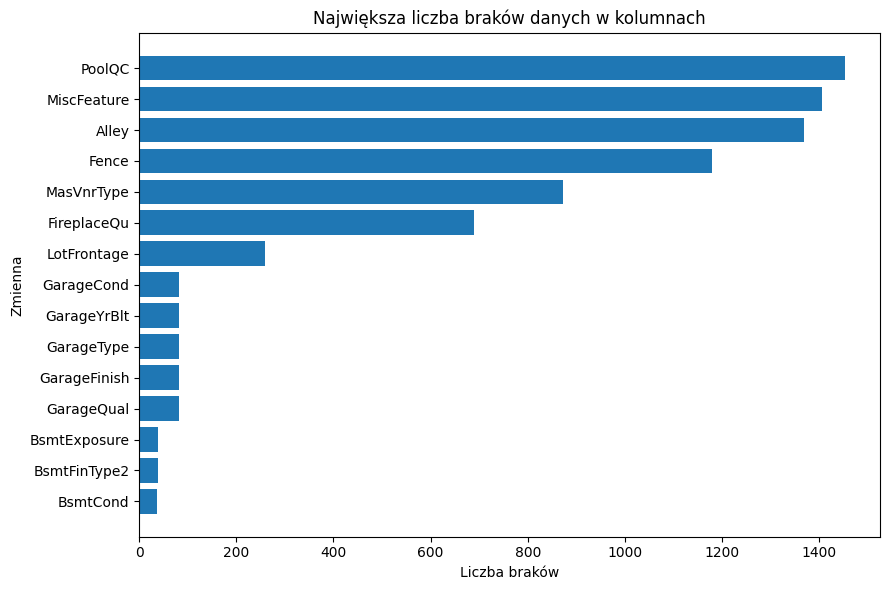

In [38]:
top_missing = missing.head(15).sort_values()
plt.figure(figsize=(9,6))
plt.barh(top_missing.index, top_missing.values)
plt.title('Największa liczba braków danych w kolumnach')
plt.xlabel('Liczba braków')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.savefig('figures/01_braki_danych.png', dpi=150)
plt.show()

**Interpretacja:** największe braki występują głównie w cechach, które logicznie mogą oznaczać brak danego elementu domu, np. brak basenu, ogrodzenia, alejki lub kominka. Takie braki nie są błędem — często oznaczają kategorię „brak”.

## 3. Czyszczenie danych

Braki w wybranych zmiennych kategorycznych uzupełniamy opisem braku danej cechy, a w zmiennych liczbowych medianą.

In [39]:
df = train.copy()
none_cols = ['Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Brak')

# pozostałe kategoryczne: najczęstsza wartość
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# liczbowe: mediana
for col in df.select_dtypes(exclude='object').columns:
    df[col] = df[col].fillna(df[col].median())

print('Pozostałe braki:', int(df.isna().sum().sum()))

Pozostałe braki: 0


## 4. Statystyki opisowe ceny domu

Analizujemy podstawowe miary: średnią, medianę, odchylenie standardowe, kwartyle, minimum i maksimum.

In [40]:
price_desc = df['SalePrice'].describe().to_frame('SalePrice')
price_desc

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


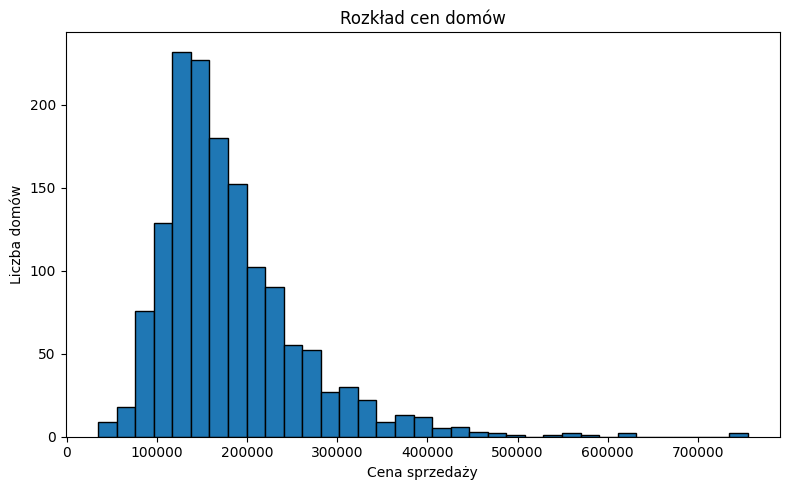

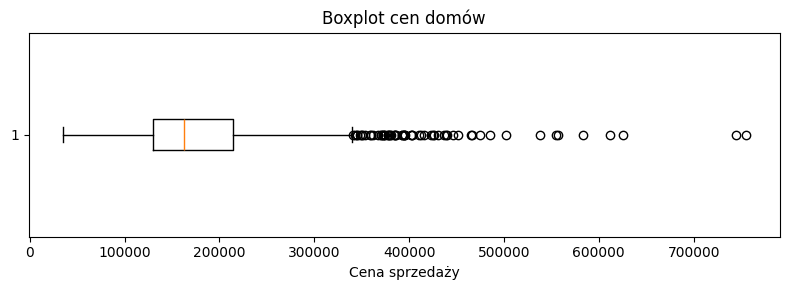

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=35, edgecolor='black')
plt.title('Rozkład cen domów')
plt.xlabel('Cena sprzedaży')
plt.ylabel('Liczba domów')
plt.tight_layout()
plt.savefig('figures/02_rozkład_cen.png', dpi=150)
plt.show()

plt.figure(figsize=(8,3))
plt.boxplot(df['SalePrice'], vert=False)
plt.title('Boxplot cen domów')
plt.xlabel('Cena sprzedaży')
plt.tight_layout()
plt.savefig('figures/03_boxplot_cen.png', dpi=150)
plt.show()

**Interpretacja:** rozkład cen jest prawostronnie skośny. Większość domów ma ceny zbliżone do dolnego i środkowego zakresu, a pojedyncze bardzo drogie domy tworzą wartości odstające. Dlatego w części analiz warto stosować także logarytm ceny, dzięki temu otrzymamy rozkład zbliżony do normalnego.

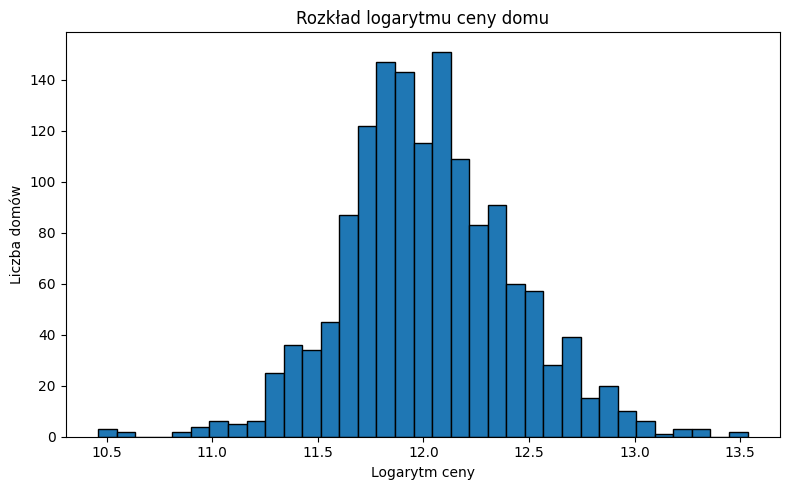

In [57]:
df['LogSalePrice'] = np.log1p(df['SalePrice'])
plt.figure(figsize=(8,5))
plt.hist(df['LogSalePrice'], bins=35, edgecolor='black')
plt.title('Rozkład logarytmu ceny domu')
plt.xlabel('Logarytm ceny')
plt.ylabel('Liczba domów')
plt.tight_layout()
plt.savefig('figures/04_log_rozkład_cen.png', dpi=150)
plt.show()

## 5. Analiza zależności i wykresy

Sprawdzamy, które cechy są powiązane z ceną domu. Analizujemy m.in. powierzchnię mieszkalną, ogólną jakość i dzielnicę.

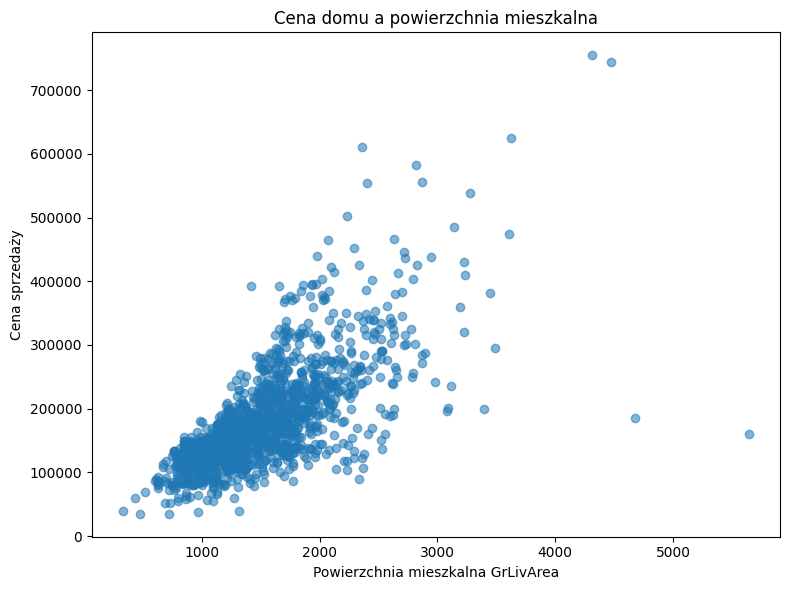

Korelacja GrLivArea z SalePrice: 0.709


In [58]:
plt.figure(figsize=(8,6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.55)
plt.title('Cena domu a powierzchnia mieszkalna')
plt.xlabel('Powierzchnia mieszkalna GrLivArea')
plt.ylabel('Cena sprzedaży')
plt.tight_layout()
plt.savefig('figures/05_cena_vs_powierzchnia.png', dpi=150)
plt.show()

corr_area = df[['GrLivArea','SalePrice']].corr().iloc[0,1]
print('Korelacja GrLivArea z SalePrice:', round(corr_area, 3))

**Interpretacja:** widoczna jest dodatnia zależność między powierzchnią mieszkalną a ceną. Większe domy zazwyczaj są droższe, chociaż zależność nie jest idealna, bo cena zależy też od innych cech.

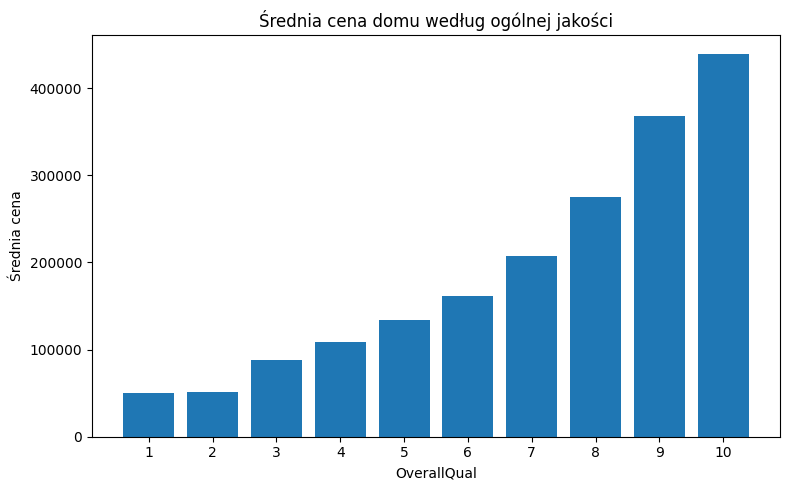

Korelacja OverallQual z SalePrice: 0.791


In [59]:
quality_mean = df.groupby('OverallQual')['SalePrice'].mean()
plt.figure(figsize=(8,5))
plt.bar(quality_mean.index.astype(str), quality_mean.values)
plt.title('Średnia cena domu według ogólnej jakości')
plt.xlabel('OverallQual')
plt.ylabel('Średnia cena')
plt.tight_layout()
plt.savefig('figures/06_cena_vs_jakosc.png', dpi=150)
plt.show()

print('Korelacja OverallQual z SalePrice:', round(df[['OverallQual','SalePrice']].corr().iloc[0,1], 3))

**Interpretacja:** średnia cena bardzo wyraźnie rośnie wraz z oceną jakości `OverallQual`. Jest to jedna z najważniejszych zmiennych w zbiorze.

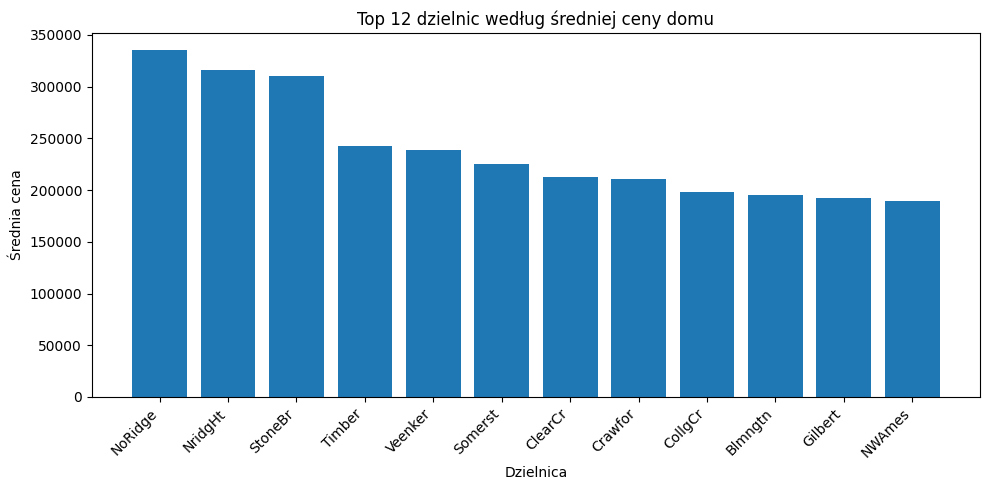

In [60]:
neigh_mean = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(12)
plt.figure(figsize=(10,5))
plt.bar(neigh_mean.index, neigh_mean.values)
plt.title('Top 12 dzielnic według średniej ceny domu')
plt.xlabel('Dzielnica')
plt.ylabel('Średnia cena')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/07_cena_vs_dzielnica.png', dpi=150)
plt.show()

**Interpretacja:** lokalizacja mocno różnicuje ceny. Dzielnice o najwyższej średniej cenie są wyraźnie droższe od pozostałych, co uzasadnia dalsze testowanie różnic między grupami.

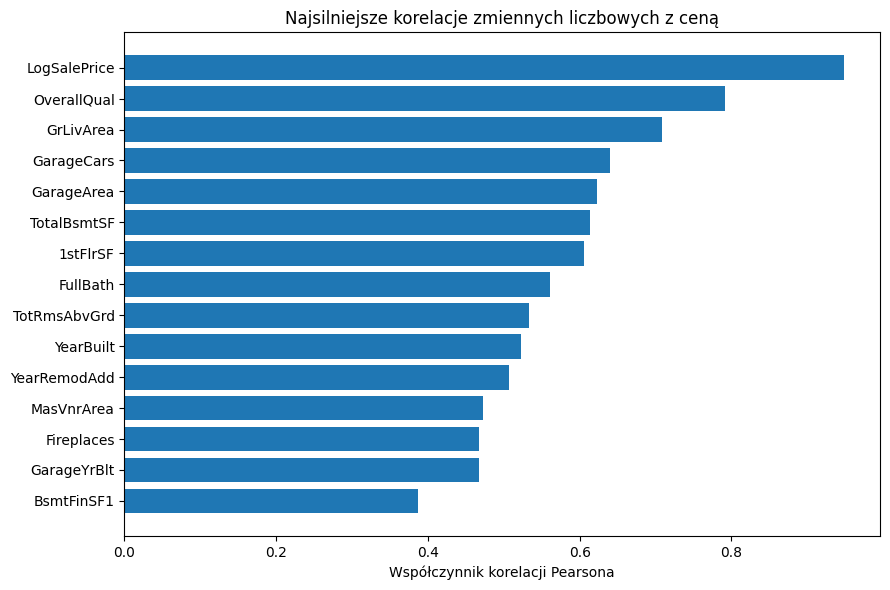

,korelacja
LogSalePrice,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [61]:
corrs = df.select_dtypes(include=np.number).corr()['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False).head(15).sort_values()
plt.figure(figsize=(9,6))
plt.barh(corrs.index, corrs.values)
plt.title('Najsilniejsze korelacje zmiennych liczbowych z ceną')
plt.xlabel('Współczynnik korelacji Pearsona')
plt.tight_layout()
plt.savefig('figures/08_korelacje_z_cena.png', dpi=150)
plt.show()
corrs.sort_values(ascending=False).to_frame('korelacja')

**Interpretacja:** najsilniej z ceną powiązane są cechy jakościowe, powierzchnia mieszkalna, liczba miejsc garażowych i wielkość garażu.

## 6. Sampling i estymacja średniej ceny

Losujemy wiele prób z danych i sprawdzamy, jak zachowuje się średnia z próby. To pokazuje sens estymacji parametrów populacji na podstawie próby.

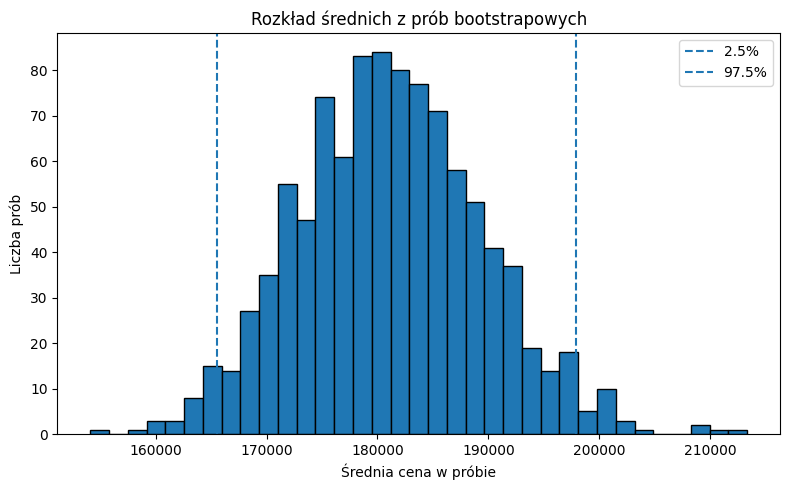

Średnia cena w danych: 180921.2
95% przedział bootstrap dla średniej: 165522.29 - 197930.17


In [47]:
np.random.seed(42)
sample_means = [df['SalePrice'].sample(100, replace=True).mean() for _ in range(1000)]
ci_low, ci_high = np.percentile(sample_means, [2.5, 97.5])

plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=35, edgecolor='black')
plt.axvline(ci_low, linestyle='--', label='2.5%')
plt.axvline(ci_high, linestyle='--', label='97.5%')
plt.title('Rozkład średnich z prób bootstrapowych')
plt.xlabel('Średnia cena w próbie')
plt.ylabel('Liczba prób')
plt.legend()
plt.tight_layout()
plt.savefig('figures/09_sampling_srednie.png', dpi=150)
plt.show()

print('Średnia cena w danych:', round(df['SalePrice'].mean(), 2))
print('95% przedział bootstrap dla średniej:', round(ci_low, 2), '-', round(ci_high, 2))

**Interpretacja:** średnie z wielu prób skupiają się wokół średniej z całego zbioru. Przedział ufności pokazuje przybliżony zakres, w którym może znajdować się prawdziwa średnia cena dla podobnej populacji domów.

## 7. Test normalności

Sprawdzamy normalność ceny oraz logarytmu ceny korzystając z testu Shapiro-Wilka.

In [ ]:
sample_price = df['SalePrice'].sample(500, random_state=42)
sample_log = df['LogSalePrice'].sample(500, random_state=42)
print('Shapiro SalePrice:', stats.shapiro(sample_price))
print('Shapiro LogSalePrice:', stats.shapiro(sample_log))

Shapiro SalePrice: ShapiroResult(statistic=np.float64(0.8290406119846443), pvalue=np.float64(1.0153279083128413e-22))
Shapiro LogSalePrice: ShapiroResult(statistic=np.float64(0.9860634774440957), pvalue=np.float64(0.000101996360702997))


**Interpretacja:** dla oryginalnej ceny normalność jest słaba, co było widać już na histogramie. Logarytm ceny jest bliższy rozkładowi normalnemu, dlatego w testach parametrycznych często analizujemy `LogSalePrice`.

## 8. Test t / test Welcha — wpływ klimatyzacji na cenę

Porównujemy ceny domów z centralną klimatyzacją (`CentralAir = Y`) i bez niej (`CentralAir = N`). Przyjmujemy hipotezy:

- H0: średnia cena w obu grupach jest taka sama,
- H1: średnia cena różni się między grupami.

Średnia cena z klimatyzacją: 186186.71
Średnia cena bez klimatyzacji: 105264.07
Test Welcha: t = 13.775 p = 2.19603596742296e-25


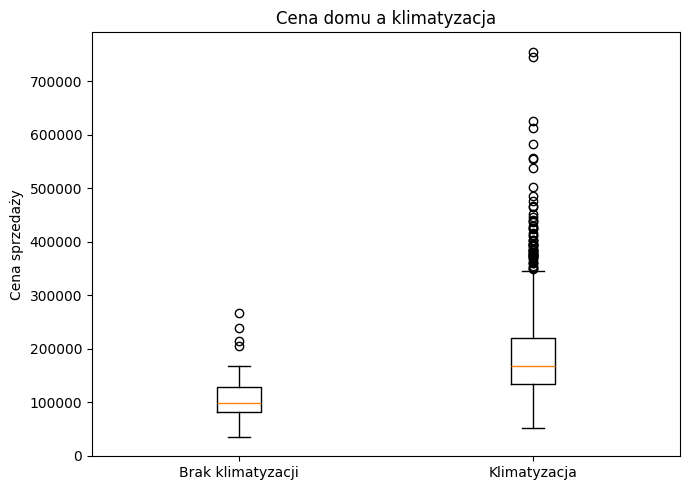

In [49]:
g_air_y = df.loc[df['CentralAir'] == 'Y', 'LogSalePrice']
g_air_n = df.loc[df['CentralAir'] == 'N', 'LogSalePrice']

t_stat, p_val = stats.ttest_ind(g_air_y, g_air_n, equal_var=False)
print('Średnia cena z klimatyzacją:', round(df.loc[df['CentralAir']=='Y','SalePrice'].mean(), 2))
print('Średnia cena bez klimatyzacji:', round(df.loc[df['CentralAir']=='N','SalePrice'].mean(), 2))
print('Test Welcha: t =', round(t_stat, 3), 'p =', p_val)

plt.figure(figsize=(7,5))
plt.boxplot([df.loc[df['CentralAir']=='N','SalePrice'], df.loc[df['CentralAir']=='Y','SalePrice']], labels=['Brak klimatyzacji','Klimatyzacja'])
plt.title('Cena domu a klimatyzacja')
plt.ylabel('Cena sprzedaży')
plt.tight_layout()
plt.savefig('figures/10_test_welcha_klimatyzacja.png', dpi=150)
plt.show()

**Interpretacja:** jeżeli wartość p jest mniejsza niż 0.05, odrzucamy H0. Wynik wskazuje, że domy z centralną klimatyzacją mają przeciętnie inną, zazwyczaj wyższą cenę niż domy bez klimatyzacji.

## 9. Test Manna–Whitneya — domy z garażem i bez garażu

Ponieważ cena nie ma idealnego rozkładu normalnego, stosujemy też test nieparametryczny Manna–Whitneya.

Mediana z garażem: 167500.0
Mediana bez garażu: 100000.0
Mann-Whitney U = 98171.0 p = 1.7361854945419468e-30


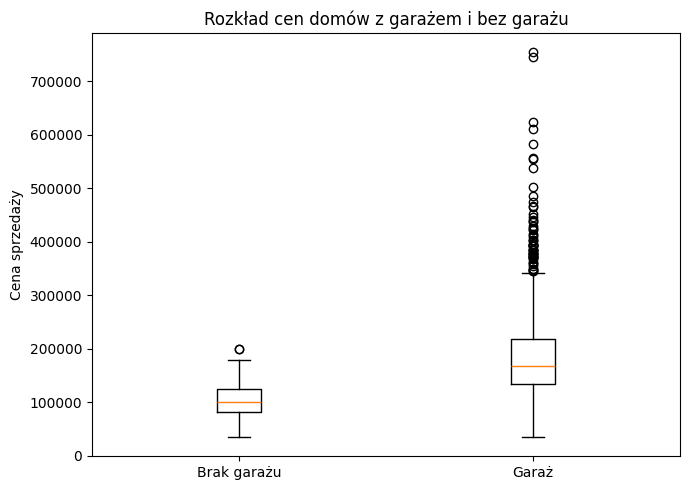

In [50]:
df['HasGarage'] = np.where(df['GarageArea'] > 0, 'Garaż', 'Brak garażu')
garage = df.loc[df['HasGarage']=='Garaż', 'SalePrice']
no_garage = df.loc[df['HasGarage']=='Brak garażu', 'SalePrice']
u_stat, p_val = stats.mannwhitneyu(garage, no_garage, alternative='two-sided')
print('Mediana z garażem:', round(garage.median(), 2))
print('Mediana bez garażu:', round(no_garage.median(), 2))
print('Mann-Whitney U =', round(u_stat, 3), 'p =', p_val)

plt.figure(figsize=(7,5))
plt.boxplot([no_garage, garage], labels=['Brak garażu','Garaż'])
plt.title('Rozkład cen domów z garażem i bez garażu')
plt.ylabel('Cena sprzedaży')
plt.tight_layout()
plt.savefig('figures/11_mann_whitney_garaz.png', dpi=150)
plt.show()

**Interpretacja:** Wynik wskazuje istotną różnicę: domy z garażem są droższe niż domy bez garażu.

## 10. Test różnic między proporcjami

Sprawdzamy, czy udział drogich domów jest inny w grupie z klimatyzacją i bez klimatyzacji. Za drogi dom przyjmujemy cenę powyżej mediany.

In [52]:
median_price = df['SalePrice'].median()
df['Expensive'] = df['SalePrice'] > median_price
ct = pd.crosstab(df['CentralAir'], df['Expensive'])
ct

Expensive,False,True
CentralAir,,
N,90,5
Y,642,723


Proporcja drogich domów z klimatyzacją: 0.53
Proporcja drogich domów bez klimatyzacji: 0.053
Test proporcji: z = 8.992 p = 2.436567653933307e-19


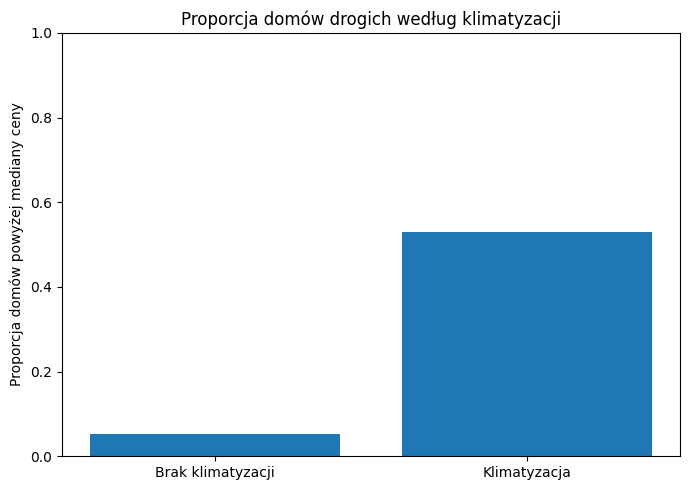

In [53]:
count = np.array([ct.loc['Y', True], ct.loc['N', True]])
nobs = np.array([ct.loc['Y'].sum(), ct.loc['N'].sum()])
z_stat, p_val = proportions_ztest(count, nobs)
print('Proporcja drogich domów z klimatyzacją:', round(count[0]/nobs[0], 3))
print('Proporcja drogich domów bez klimatyzacji:', round(count[1]/nobs[1], 3))
print('Test proporcji: z =', round(z_stat, 3), 'p =', p_val)

props = [count[1]/nobs[1], count[0]/nobs[0]]
plt.figure(figsize=(7,5))
plt.bar(['Brak klimatyzacji','Klimatyzacja'], props)
plt.title('Proporcja domów drogich według klimatyzacji')
plt.ylabel('Proporcja domów powyżej mediany ceny')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('figures/13_test_proporcji.png', dpi=150)
plt.show()

**Interpretacja:** Wynik pokazuje, że tylko 5% domów bez klimatyzacji jest uważana za drogie w porównaniu do 54% z domami, które mają klimatyzację.

## 12. ANOVA — różnice cen między dzielnicami

ANOVA sprawdza, czy średnie ceny w wielu grupach są takie same. Tutaj grupami są dzielnice (`Neighborhood`). Analizujemy logarytm ceny.

In [54]:
model_anova = smf.ols('LogSalePrice ~ C(Neighborhood)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Neighborhood),132.882772,24.0,79.520526,4.041201e-243
Residual,99.914862,1435.0,NaN,NaN


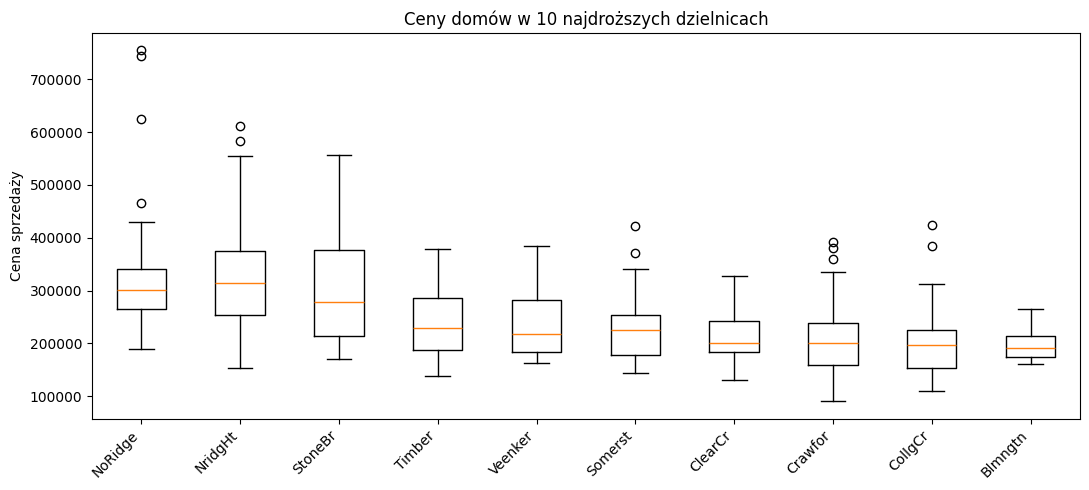

In [55]:
top_neigh = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(10).index
subset = [df.loc[df['Neighborhood']==n, 'SalePrice'] for n in top_neigh]
plt.figure(figsize=(11,5))
plt.boxplot(subset, labels=top_neigh)
plt.title('Ceny domów w 10 najdroższych dzielnicach')
plt.ylabel('Cena sprzedaży')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/14_anova_dzielnice.png', dpi=150)
plt.show()

**Interpretacja:** dzielnica ma istotny związek z ceną domu. Wykres pokazuje, że rozkłady cen między dzielnicami wyraźnie się różnią.

## 13. ANCOVA — wpływ dzielnicy po kontroli powierzchni

Sprawdzamy wpływ dzielnicy przy kontroli powierzchni mieszkalnej `GrLivArea`.

In [56]:
model_ancova = smf.ols('LogSalePrice ~ GrLivArea + C(Neighborhood)', data=df).fit()
ancova_table = sm.stats.anova_lm(model_ancova, typ=2)
ancova_table

,sum_sq,df,F,PR(>F)
C(Neighborhood),62.276612,24.0,66.271937,2.508775e-212
GrLivArea,43.767001,1.0,1117.796439,1.095429e-181
Residual,56.147861,1434.0,NaN,NaN


**Interpretacja:** jeśli zarówno `GrLivArea`, jak i `Neighborhood` mają p-value < 0.05, oznacza to, że cena zależy jednocześnie od powierzchni i od lokalizacji. Innymi słowy, dzielnica nadal ma znaczenie nawet po uwzględnieniu wielkości domu.

## 14. Wnioski końcowe

1. Najważniejsze czynniki powiązane z ceną to ogólna jakość domu, powierzchnia mieszkalna, garaż, lokalizacja i rok budowy.
2. Domy z klimatyzacją oraz domy z garażem mają przeciętnie wyższe ceny.
3. Dzielnica istotnie różnicuje ceny domów, co potwierdza ANOVA.
4. Po kontroli powierzchni mieszkalnej lokalizacja nadal pozostaje istotna, co potwierdza ANCOVA.
